#AML Investigation Project – iGaming Sector

##OBJECTIVE:
To audit a fictional dataset containing over 100,000 transactions in order to identify potential indicators of Money Laundering (ML), fraud, and regulatory non-compliance within an iGaming environment.

##METHODOLOGY:
1 - **1. Data Generation**

A Python script was used to generate three CSV datasets:

a) ***User Dataset*** (`users`):

Contains customer profile information and digital identity attributes.

*   **user_id**: Unique customer identifier.
*   **cpf**: Brazilian Taxpayer Identification Number (relevant for sanctions and watchlist screening procedures).
*   **registration_ip**: IP address used during account creation.
*   **registration_date**: Date the customer registered on the platform.

b) ***Transaction Dataset*** (`transactions`):

Contains records of all financial inflows and outflows.

*   **id**: Unique transaction identifier.
*   **user_id**: Customer identifier associated with the transaction.
*   **amount**: Monetary value of the transaction.
*   **type**: Transaction category (deposit or withdrawal).
*   **payment_method**: Payment channel used (PIX, Credit Card, or Bank Slip).
*   **timestamp**: Exact date and time of the transaction, enabling transaction velocity analysis.
*   **transaction_ip**: IP address from which the financial instruction originated, supporting the identification of suspicious behaviors such as account sharing, bonus abuse, mule account activity, and other fraud typologies.

c) ***Betting Activity Dataset*** (`bets`)

Contains customer gaming behavior records.

*   **id**: Unique betting identifier.
*   **user_id**: Customer identifier.
*   **bet_amount**: Amount wagered.
*   **outcome:**: etting result (Win/Loss).
*   **timestamp**: Exact date and time of the betting activity.

2 - **2. Transaction Monitoring & Red Flag Detection**

The analysis focuses on identifying potentially suspicious patterns, including:

**IP Sharing**

Multiple customer accounts conducting financial activity from the same IP address, potentially indicating account sharing, synthetic identities, coordinated activity, or other forms of abuse.

**Structuring(Smurfing):**

Repeated deposits intentionally fragmented into smaller amounts in an apparent attempt to avoid transaction monitoring thresholds and detection controls.

**3. Risk Assessment & Recommendations**

Each identified alert is assessed according to its associated ML/TF risk indicators, resulting in:


*   Risk classification;
*   Investigative rationale;
*   Recommended control measures;
*   Enhanced Due Diligence (EDD) actions where applicable.


##REGULATORY FRAMEWORK
This analysis is conducted from an Anti-Money Laundering and Counter-Terrorist Financing (AML/CFT) perspective, taking into consideration the following regulatory and international standards:

**Financial Action Task Force (FATF) Recommendations**

Particular emphasis is placed on:


*   Recommendation 1 (Risk-Based Approach);
*   Recommendation 22;
*   Recommendation 23.

**Brazilian AML Law (Law No. 9,613/1998)**

Brazil's primary AML/CFT legislation, which establishes obligations for designated reporting entities, including gaming and betting operators, regarding customer identification, recordkeeping, transaction monitoring, and suspicious activity reporting.

**SPA/MF Ordinance No. 1,143/2024**

Regulatory framework establishing AML/CFT compliance requirements for Brazil's regulated betting and iGaming sector, including the implementation of internal controls, monitoring procedures, and risk-based compliance programs.

##Deliverables
Upon completion of the investigation, the following outputs are produced:

*   Risk Assessment Matrix;
*   Documented Investigative Findings;
*   Enhanced Due Diligence (EDD) Recommendations;
*   Final AML Investigation Memorandum.




In [11]:
## Synthetic Dataset Generation

import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Database Setup and Data Generation
conn = sqlite3.connect('aml_investigation.db')
cursor = conn.cursor()

def generate_aml_data(n_users=1000, n_transactions=100000):
    # Generating User Dataset
    user_ids = np.arange(1, n_users + 1)
    cpfs = [f"{np.random.randint(100,999)}.{np.random.randint(100,999)}.{np.random.randint(100,999)}-{np.random.randint(10,99)}" for _ in range(n_users)]

    # Criando IPs (alguns repetidos para simular laranjas)
    common_ips = [f"192.168.1.{np.random.randint(1,50)}" for _ in range(10)]
    ips = [np.random.choice(common_ips) if np.random.rand() < 0.1 else f"{np.random.randint(100,255)}.{np.random.randint(0,255)}.{np.random.randint(0,255)}.{np.random.randint(0,255)}" for _ in range(n_users)]

    users_df = pd.DataFrame({
        'user_id': user_ids,
        'cpf': cpfs,
        'ip_cadastro': ips,
        'data_registro': [datetime(2025, 1, 1) + timedelta(days=np.random.randint(0, 400)) for _ in range(n_users)]
    })

    # Generating Transaction Records
    trans_ids = np.arange(1, n_transactions + 1)
    types = ['deposito', 'saque']
    methods = ['PIX', 'Cartão de Crédito', 'Boleto']

    trans_data = []
    base_date = datetime(2026, 1, 1)
    data_final = datetime(2026, 5, 4, 18, 0)
    delta_segundos = int((data_final - base_date).total_seconds())

    for i in range(n_transactions):
        uid = np.random.choice(user_ids)
        t_type = np.random.choice(types, p=[0.7, 0.3]) # More deposits than withdrawals
        val = np.random.exponential(scale=500) # Most transactions are low-value

        # Intentionally injecting high-value transaction anomalies
        if i % 5000 == 0:
            val = np.random.uniform(50000, 150000)

        trans_data.append([
            i+1, uid, round(val, 2), t_type,
            np.random.choice(methods),
            base_date + timedelta(seconds=np.random.randint(0, delta_segundos)),
            users_df.loc[users_df['user_id'] == uid, 'ip_cadastro'].values[0]
        ])

    trans_df = pd.DataFrame(trans_data, columns=['id', 'user_id', 'valor', 'tipo', 'metodo', 'timestamp', 'ip_transacao'])

    # Exporting datasets to SQLite database
    users_df.to_sql('users', conn, if_exists='replace', index=False)
    trans_df.to_sql('transactions', conn, if_exists='replace', index=False)

    print("✅ Banco de dados 'aml_investigation.db' criado com sucesso!")
    print(f"📊 Tabelas: 'users' ({len(users_df)} linhas) e 'transactions' ({len(trans_df)} linhas)")

generate_aml_data()

✅ Banco de dados 'aml_investigation.db' criado com sucesso!
📊 Tabelas: 'users' (1000 linhas) e 'transactions' (100000 linhas)


In [12]:
## Testing querries
query = """
SELECT * FROM transactions
LIMIT 10;
"""
pd.read_sql(query, conn)

,id,user_id,valor,tipo,metodo,timestamp,ip_transacao
0,1,247,59928.08,deposito,PIX,2026-03-23 13:42:04,225.152.159.92
1,2,440,195.81,deposito,PIX,2026-02-03 22:20:43,217.161.141.6
2,3,826,637.68,deposito,Cartão de Crédito,2026-03-10 04:16:00,192.168.1.33
3,4,781,773.73,deposito,PIX,2026-04-14 05:05:13,182.252.212.84
4,5,789,1878.26,saque,PIX,2026-03-21 10:50:49,192.168.1.33
5,6,464,83.26,deposito,PIX,2026-02-07 12:14:40,200.170.4.27
6,7,562,664.41,deposito,Boleto,2026-04-10 14:12:18,192.168.1.33
7,8,25,726.24,deposito,Boleto,2026-03-25 09:38:49,192.168.1.39
8,9,195,653.88,saque,PIX,2026-01-21 10:23:28,204.223.49.44
9,10,253,1348.67,deposito,Cartão de Crédito,2026-02-04 03:05:48,209.233.176.117


In [13]:
## Function to facilitate the use of SQL
def sql(query):
    return pd.read_sql(query, conn)

# **INVESTIGATION (N0001):** IP Sharing Detection
**Hypothesis:** A single operator may be controlling multiple accounts registered under different CPF numbers to facilitate the structuring and dispersion of funds, potentially obscuring beneficial ownership and reducing the visibility of suspicious activity.

In [14]:
# Objective: Detect instances where multiple customer accounts and CPF numbers are conducting financial activity from the same IP address.
# The analysis focuses exclusively on IP addresses associated with more than one user account, as these may indicate account sharing, mule-account activity, or other suspicious behaviors.

query_ip_investigation = """
SELECT
    t.ip_transacao             AS endereco_ip,
    COUNT(DISTINCT u.user_id)  AS total_usuarios,
    COUNT(t.id)                AS volume_transacoes,
    GROUP_CONCAT(DISTINCT u.cpf) AS lista_cpfs_suspeitos
FROM transactions AS t
JOIN users AS u
    ON t.user_id = u.user_id
GROUP BY 1
HAVING total_usuarios > 1
ORDER BY total_usuarios DESC;
"""

sql(query_ip_investigation)

,endereco_ip,total_usuarios,volume_transacoes,lista_cpfs_suspeitos
0,192.168.1.1,16,1625,"570.619.789-32,260.297.172-50,237.204.351-61,4..."
1,192.168.1.21,13,1317,"167.253.774-31,239.296.209-76,411.365.149-43,7..."
2,192.168.1.18,13,1251,"580.265.281-73,653.443.589-54,250.572.388-86,6..."
3,192.168.1.8,12,1198,"534.945.270-36,801.747.145-20,458.172.804-85,5..."
4,192.168.1.39,10,994,"101.462.354-28,927.380.185-59,173.607.483-50,7..."
5,192.168.1.9,9,871,"672.515.302-94,505.781.758-79,984.654.708-25,7..."
6,192.168.1.24,9,897,"696.126.197-75,833.473.772-50,351.282.410-86,2..."
7,192.168.1.33,8,828,"199.382.473-31,731.669.568-44,650.771.568-85,9..."
8,192.168.1.4,7,690,"415.294.691-73,252.402.103-92,315.917.879-28,1..."
9,192.168.1.38,6,602,"836.428.795-16,279.305.741-76,702.625.358-26,9..."


#**INVESTIGATION NOTE (N0001)**
Through exploratory analysis, a risk typology involving IP address overlap across multiple distinct CPF numbers was identified. This behavior is strongly associated with identity fraud, bonus abuse schemes, and the use of nominee accounts (mule accounts) to conceal the true beneficial owner of the funds.

##**1. Risk Assessment Analysis:**

###**Likelihood** (`Rating 5/5 – Almost Certain`):

The maximum rating is justified as IP overlap is one of the primary indicators of multi-accounting activity and the use of nominee accounts. The repeated detection of multiple CPF numbers conducting activity through a common network endpoint significantly increases the likelihood of identity fraud, account abuse, or money laundering activity, exceeding the expected level of legitimate activity observed in shared-network environments.

###**IMPACT** (`Rating 4/5 – Severe`):

The materialization of this risk may compromise the effectiveness of the institution's AML/CFT compliance framework, exposing the organization to regulatory scrutiny and potential sanctions resulting from failures in customer identification and beneficial ownership verification procedures.

Furthermore, the use of mule accounts may facilitate financial fraud, bonus abuse, and the concealment of suspicious financial activity, generating direct operational losses and reputational risks for the platform.

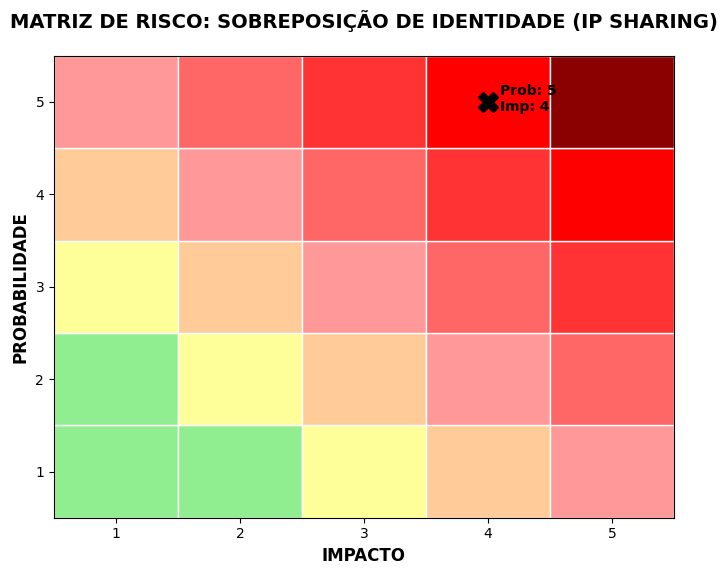

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 5x5 Risk Matrix Configuration
fig, ax = plt.subplots(figsize=(8, 6))
matrix = np.zeros((5, 5))

# Setting risk zone colors (Compliance Heatmap Pattern)
colors = [
    ['#90ee90', '#90ee90', '#ffff99', '#ffcc99', '#ff9999'], # Line 1
    ['#90ee90', '#ffff99', '#ffcc99', '#ff9999', '#ff6666'], # Line 2
    ['#ffff99', '#ffcc99', '#ff9999', '#ff6666', '#ff3333'], # Line 3
    ['#ffcc99', '#ff9999', '#ff6666', '#ff3333', '#ff0000'], # Line 4
    ['#ff9999', '#ff6666', '#ff3333', '#ff0000', '#8b0000']  # Line 5
]

# Draw Matrix Cells
for i in range(5):
    for j in range(5):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j], ec='white'))

# RISK MARKER: LIKELIHOOD 5, IMPACT 4
# Since chart coordinates start at 0, a rating of 4 corresponds to index 3.
ax.plot(3.5, 4.5, marker='X', color='black', markersize=15, label='Risco Identificado: IP Sharing')

# Axis Settings
ax.set_xticks(np.arange(0.5, 5.5, 1))
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticks(np.arange(0.5, 5.5, 1))
ax.set_yticklabels(['1', '2', '3', '4', '5'])

ax.set_xlabel('IMPACTO', fontsize=12, fontweight='bold')
ax.set_ylabel('PROBABILIDADE', fontsize=12, fontweight='bold')
ax.set_title('MATRIZ DE RISCO: SOBREPOSIÇÃO DE IDENTIDADE (IP SHARING)', fontsize=14, pad=20, fontweight='bold')

# Subtitles
plt.text(3.6, 4.4, 'Prob: 5\nImp: 4', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, 5)
plt.ylim(0, 5)
plt.grid(False)
plt.show()

##**2. RECOMMENDATIONS**:
Based on the findings above, the following actions are recommended:

**EDD (Enhanced Due Diligence)**:

Apply Enhanced Due Diligence procedures to the identified CPF numbers in order to validate the legitimacy of customer information, verify the source of funds, and assess whether the observed activity is consistent with the customer's expected profile.

**Preventive Account Restriction**:

Consider the temporary restriction or suspension of accounts exhibiting the highest transactional volumes until account ownership, source of funds, and the legitimacy of the activity can be adequately verified.

**Suspicious Activity Escalation**:

If no reasonable explanation is provided for the recurring IP address sharing patterns, the identified accounts should be escalated for formal review and inclusion in a Suspicious Activity Report (SAR) assessment process, in accordance with applicable AML/CFT regulations and the requirements established under Brazilian Law No. 9,613/1998.


In [16]:
# Exporting list of IP adresses and CPFs to Enhanced Due Diligence(EDD)
df_suspeitos_ip = sql(query_ip_investigation)
df_suspeitos_ip.to_csv('alerta_ip_sharing_2026-05-04.csv', index=False)

print("✅ Relatório de Suspeitos gerado com sucesso: alerta_ip_sharing_2026-05-04.csv")

✅ Relatório de Suspeitos gerado com sucesso: alerta_ip_sharing_2026-05-04.csv


##**3. Enhanced Due Diligence (EDD) Action Plan**

For the identified accounts, the investigation team should request and validate the following information within 48 hours:

**Identity Verification and Liveness Check:**

Request a new biometric verification (selfie) together with a valid government-issued identification document and current date validation to mitigate the risk of stolen identities, synthetic identities, or account impersonation.

**Source of Funds and Financial Capacity Assessment:**

Request supporting documentation, such as bank statements, proof of income, or other relevant financial records, to determine whether the customer's financial profile is consistent with the observed transactional activity and to assess potential nominee-account indicators.

**Device Fingerprinting Review:**

Verify whether the identified accounts share additional technical attributes beyond the IP address, including:

*   Device ID;
*   Operating system version;
*   Browser characteristics;
*   Screen resolution;
*   Other available device fingerprinting indicators.

The presence of multiple matching attributes may strengthen indications of coordinated account control.

**Relationship Verification:**

Formally request clarification regarding the relationship between account holders operating from the same network location, including but not limited to:

*   Family relationship;
*   Shared residence;
*   Employment relationship;
*   Other legitimate explanations for the observed network overlap.

The responses should be assessed for consistency with the customer's profile and transactional behavior.


#**INVESTIGATION N0010: Potential Structuring Activity**

**Hypothesis:** Transaction patterns suggest potential structuring behavior, whereby a customer repeatedly conducts deposits below reporting or monitoring thresholds in order to obscure the true volume of funds entering the platform and reduce the likelihood of automated alert generation.

.
**Target Population:** Customers exhibiting:

*   High deposit frequency;
*   Significant aggregate deposit volume;
*   Relatively low average transaction values;
*   Transaction patterns potentially consistent with structuring activity.



In [17]:
## Objective: Identify customers exhibiting a high frequency of deposits during April
# and whose aggregate transaction volume may indicate potential structuring activity
# designed to circumvent transaction monitoring controls.

query_smurfing_outliers = """
SELECT
    u.user_id,
    u.cpf,
    COUNT(t.id) AS qtd_depositos,
    SUM(t.valor) AS volume_total,
    AVG(t.valor) AS media_valor,
    -- Criando uma lógica de risco:
    CASE
        WHEN SUM(t.valor) > 50000 THEN 'Altíssimo Risco'
        WHEN COUNT(t.id) > 30 THEN 'Suspeita de Automação'
        ELSE 'EDD'
    END AS classificacao_risco
FROM transactions AS t
JOIN users AS u ON t.user_id = u.user_id
WHERE t.tipo = 'deposito'
  AND t.timestamp BETWEEN '2026-04-01' AND '2026-04-30'
GROUP BY u.user_id, u.cpf
HAVING qtd_depositos > 20 AND volume_total > 15000
ORDER BY volume_total DESC;
"""

df_smurfing = sql(query_smurfing_outliers)
df_smurfing

,user_id,cpf,qtd_depositos,volume_total,media_valor,classificacao_risco
0,74,897.332.466-32,30,22843.37,761.445667,EDD
1,514,779.193.923-60,23,20269.61,881.287391,EDD
2,450,340.577.634-96,25,19200.23,768.009200,EDD
3,418,280.198.789-34,22,18912.81,859.673182,EDD
4,621,373.675.859-57,27,18456.09,683.558889,EDD
5,731,358.648.754-86,24,17967.14,748.630833,EDD
6,94,252.885.980-43,24,17525.30,730.220833,EDD
7,75,751.632.944-89,26,16743.44,643.978462,EDD
8,415,377.914.626-80,32,16236.57,507.392813,Suspeita de Automação
9,222,633.132.525-83,24,16163.75,673.489583,EDD


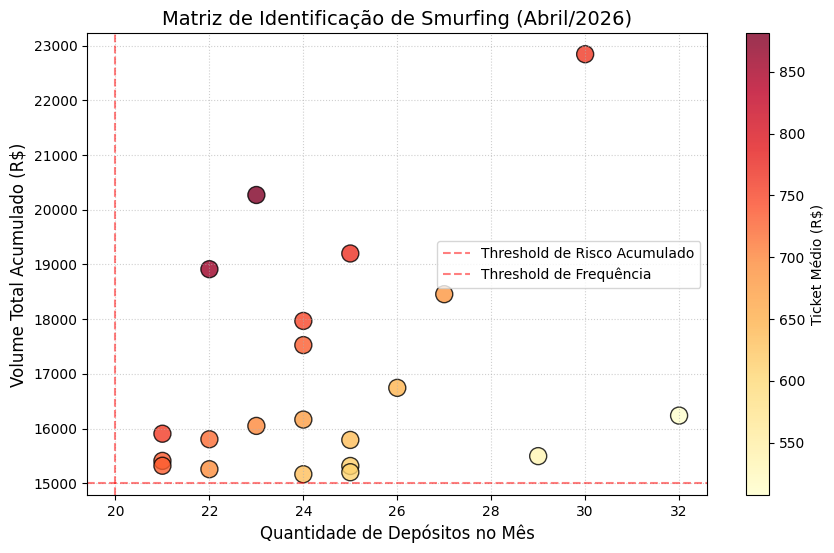

In [18]:
## Creating a Scatter Chart to better visualize the smurfing pattern

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Plotting the results found
plt.scatter(df_smurfing['qtd_depositos'], df_smurfing['volume_total'],
            c=df_smurfing['media_valor'], cmap='YlOrRd', s=150, edgecolors='black', alpha=0.8)

plt.colorbar(label='Ticket Médio (R$)')
plt.axhline(y=15000, color='red', linestyle='--', alpha=0.5, label='Threshold de Risco Acumulado')
plt.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Threshold de Frequência')

plt.title('Matriz de Identificação de Smurfing (Abril/2026)', fontsize=14)
plt.xlabel('Quantidade de Depósitos no Mês', fontsize=12)
plt.ylabel('Volume Total Acumulado (R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#**INVESTIGATION NOTE (N0010)**

Through transaction monitoring activities, a risk typology consistent with potential structuring (smurfing) behavior was identified.

This pattern is characterized by the execution of multiple low-value deposit transactions that collectively result in a significant aggregate amount. Such activity may be intended to reduce the visibility of fund inflows and avoid transaction monitoring thresholds typically associated with high-value transactions.

##**1. Risk Assessment Analysis**

**Likelihood** (`Rating 4/5 – High`)

The elevated rating is supported by the unusually high deposit frequency observed among the identified customers, averaging between 25 and 29 deposits per month.

Although recurring deposits are common within the iGaming sector, the combination of high transaction frequency and aggregate deposit volumes exceeding BRL 15,000 is inconsistent with typical recreational gaming behavior and may indicate deliberate transaction structuring.

**Impact** (`Rating 4/5 – Severe`):

Structuring is a well-recognized money laundering typology frequently associated with the placement stage of the laundering process.

Failure to detect and investigate this behavior may expose the platform to risks involving the movement of illicit funds, regulatory non-compliance, and deficiencies in transaction monitoring controls.

Additionally, inadequate detection of such activity may increase exposure to regulatory scrutiny, financial penalties, and reputational damage under applicable AML/CFT requirements.



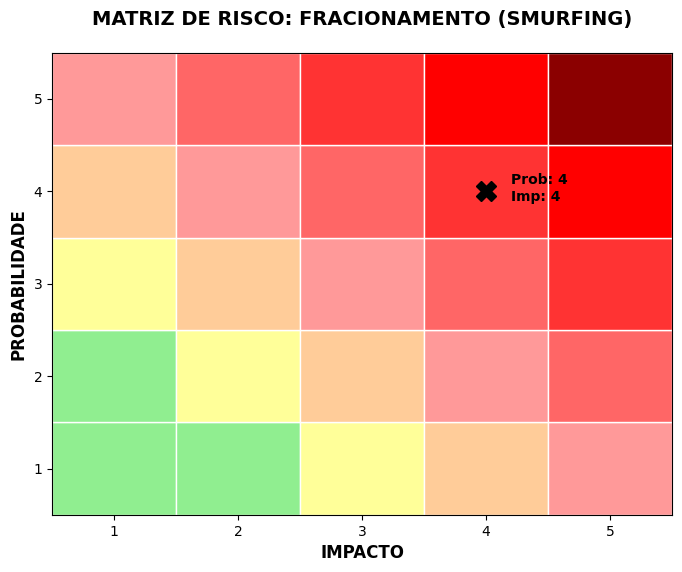

In [19]:
# Risk Matrix Visualization

import matplotlib.pyplot as plt
import numpy as np

# 5x5 Risk Matrix Configuration
fig, ax = plt.subplots(figsize=(8, 6))
matrix = np.zeros((5, 5))

# Defining color zones according to risk level
# 1-2: Green (Low), 3: Yellow (Moderate), 4: Orange (High), 5: Red (Critical)
colors = [
    ['#90ee90', '#90ee90', '#ffff99', '#ffcc99', '#ff9999'],
    ['#90ee90', '#ffff99', '#ffcc99', '#ff9999', '#ff6666'],
    ['#ffff99', '#ffcc99', '#ff9999', '#ff6666', '#ff3333'],
    ['#ffcc99', '#ff9999', '#ff6666', '#ff3333', '#ff0000'],
    ['#ff9999', '#ff6666', '#ff3333', '#ff0000', '#8b0000']
]

# Draw matrix cells
for i in range(5):
    for j in range(5):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j], ec='white'))

# RISK MARKER: LIKELIHOOD 4, IMPACT 4
# Since chart coordinates start at 0, a rating of 4 corresponds to index 3.
ax.plot(3.5, 3.5, marker='X', color='black', markersize=15, label='Risco Identificado: Smurfing')

# Axis Settings
ax.set_xticks(np.arange(0.5, 5.5, 1))
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticks(np.arange(0.5, 5.5, 1))
ax.set_yticklabels(['1', '2', '3', '4', '5'])

ax.set_xlabel('IMPACTO', fontsize=12, fontweight='bold')
ax.set_ylabel('PROBABILIDADE', fontsize=12, fontweight='bold')
ax.set_title('MATRIZ DE RISCO: FRACIONAMENTO (SMURFING)', fontsize=14, pad=20, fontweight='bold')


plt.text(3.7, 3.4, 'Prob: 4\nImp: 4', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, 5)
plt.ylim(0, 5)
plt.grid(False)
plt.show()

## **2. Recommendations**

Based on the potential structuring indicators identified across the 19 customer accounts analyzed, the following actions are recommended:

### **Enhanced Due Diligence (EDD)**

Apply Enhanced Due Diligence procedures to the identified customers due to the atypical transactional behavior observed, characterized by a high volume of low-value deposits conducted within a relatively short period, resulting in significant aggregate transaction amounts.

The review should focus on validating the customer's profile, assessing the legitimacy of the activity, and verifying whether the observed transaction patterns are consistent with the customer's expected financial behavior.

### **Suspicious Activity Escalation**

If no reasonable business or personal justification is provided for the unusually high volume and frequency of deposit activity, the identified accounts should be escalated for formal review and consideration within the Suspicious Activity Report (SAR) assessment process, in accordance with applicable AML/CFT regulations and Brazilian Law No. 9,613/1998.

## **3. Enhanced Due Diligence (EDD) Action Plan**

For the identified customers, the investigation team should request and validate the following information within 48 hours:

### **Source of Wealth (SoW) Assessment**

Request supporting documentation, such as payslips, tax returns, or bank statements, to verify that the customer's financial profile is consistent with monthly deposits exceeding BRL 15,000. The objective is to determine whether the customer may be acting as a potential money mule.

### **Counterparty Traceability Review (PIX Key Analysis)**

Assess whether the multiple structured deposits originate from the same PIX key or from third-party CPF numbers. Deposits originating from numerous unrelated sources and converging into a single gaming account may represent a significant indicator of placement-stage money laundering activity.

### **Betting Activity and Rollover Analysis**

Review whether the deposited funds were effectively used for gaming activity or whether withdrawal requests (cash-outs) were submitted shortly after the accumulation of deposits.

A significant mismatch between deposited amounts and actual betting activity may indicate that the account is being used primarily as a vehicle for fund movement rather than legitimate gaming activity.

### **Destination Account Monitoring**

Verify whether funds are ultimately withdrawn to bank accounts that differ from the account holder originally registered on the platform.

Such activity may indicate attempts to obscure the ownership trail of funds and could be consistent with later stages of the money laundering process.

Pequena observação AML: eu troquei "Source of Wealth" por uma análise que mistura um pouco Source of

# **CONSOLIDATED AML INVESTIGATION REPORT (iGAMING SECTOR)**

**Date:** May 5, 2026

**Prepared by:** Pedro Paolucci

**Status:** Completed – Pending Compliance Officer Review

## **1. Executive Summary**

This project simulated a data audit environment within an online betting and gaming platform, analyzing a dataset containing over 100,000 financial transactions conducted between January and May 2026.

Data analysis techniques and SQL-based transaction monitoring procedures were applied to identify behavioral patterns and anomalies potentially associated with Money Laundering, Identity Fraud, and other forms of financial crime.

## **2. Investigation Results**

### **A) Typology: Identity Overlap (IP Sharing)**

**Focus:** Identification of infrastructure potentially used to facilitate money laundering through nominee accounts (mule accounts).

**Finding:** Detection of IP addresses shared by up to seven distinct CPF numbers.

**Risk Rating:** Likelihood 5/5 | Impact 4/5

**Status:** Escalated for Preventive Restriction, Enhanced Due Diligence (EDD), and potential Suspicious Activity Report (SAR) assessment.

---

### **B) Typology: Structuring (Smurfing)**

**Focus:** Detection of transaction patterns potentially designed to circumvent transaction monitoring thresholds.

**Finding:** Identification of customers exhibiting unusually high deposit frequency (average of 26 deposits per month), resulting in aggregate deposited amounts exceeding BRL 15,000 while maintaining relatively low average transaction values (below BRL 700).

**Risk Rating:** Likelihood 4/5 | Impact 4/5

**Status:** Escalated for Enhanced Due Diligence (EDD) and potential Suspicious Activity Report (SAR) assessment.

## **3. Regulatory and Compliance Framework**

The project was developed in accordance with Brazilian AML/CFT regulatory principles and industry best practices, including:

* **Financial Action Task Force (FATF) Recommendations**;

* **Brazilian Law No. 9,613/1998** – Anti-Money Laundering and Counter-Terrorist Financing legislation;

* **BCB Resolution No. 44/2020** – Requirements regarding the monitoring and reporting of suspicious financial activities;

* **SPA/MF Regulatory Guidelines** – Regulatory framework applicable to the fixed-odds betting and iGaming sector.

## **4. Conclusion**

The investigation successfully identified two high-risk typologies commonly associated with financial crime within digital gaming environments:

1. **Multi-Accounting and Identity Overlap through Shared IP Infrastructure;**

2. **Potential Structuring (Smurfing) through High-Frequency, Low-Value Deposits.**

The identified behaviors warrant further investigation through Enhanced Due Diligence procedures and ongoing transaction monitoring to determine whether the activity is consistent with legitimate customer behavior or indicative of potential money laundering, fraud, or related financial crime risks.

This project demonstrates the practical application of SQL, Python, transaction monitoring methodologies, risk-based analysis, and AML/CFT investigative procedures within a simulated iGaming compliance environment.